In [5]:
# Importations de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score

# Modèles de régression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Optimisation
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Configuration
%matplotlib inline

# Vérification et application du style
if 'seaborn-v0_8' in plt.style.available:
    plt.style.use('seaborn-v0_8')
elif 'seaborn' in plt.style.available:
    plt.style.use('seaborn')
else:
    plt.style.use('ggplot')  # Style de repli

pd.set_option('display.max_columns', 100)
warnings.filterwarnings('ignore')

In [6]:
# Charger le DataFrame final
try:
    df = pd.read_csv(r"C:\\Users\\zizou\\OneDrive\\Desktop\\stage 3ème\\day 2\\csvfiles\\dataframefinale.csv", sep=';', encoding='utf-8')
    print(f"Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Erreur: Fichier 'dataframefinale.csv' non trouvé. Vérifiez le chemin.")
    df = pd.DataFrame()  # Crée un DataFrame vide pour éviter les erreurs

Shape: (19995, 13)


,dataloadingdate,Jour,Mois,NumeroSemaine,Trimestre,JourSemaineNum,JourSemaine,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.6
1,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.5
2,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.6
3,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.6
4,01/07/2025,1,7,27,3,1,Tuesday,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.1


In [7]:
if not df.empty:
    # Suppression des colonnes non pertinentes
    cols_to_drop = ['dataloadingdate', 'JourSemaine', 'ISIN', 'Libellé']
    df_clean = df.drop([col for col in cols_to_drop if col in df.columns], axis=1)
    
    # Conversion des variables catégorielles si nécessaire
    # df_clean = pd.get_dummies(df_clean, columns=['cat_column'], drop_first=True)
    
    # Séparation features/target
    X = df_clean.drop('Montant', axis=1)
    y = df_clean['Montant']
    
    # Split train/test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42
    )
    print("Préparation des données terminée.")
else:
    print("Erreur: Impossible de préparer les données (DataFrame vide).")

Préparation des données terminée.


In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, show_plot=True):
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Métriques
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    r2 = r2_score(y_test, test_pred)
    
    # Affichage
    print(f"=== Résultats pour {model_name} ===")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"R² Score: {r2:.4f}\n")
    
    # Visualisation
    if show_plot:
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, test_pred, alpha=0.5)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
        plt.xlabel('Valeurs Réelles')
        plt.ylabel('Prédictions')
        plt.title(f'Valeurs Réelles vs Prédictions - {model_name}')
        plt.show()
    
    return {
        'model_name': model_name,
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': r2
    }

=== Résultats pour Linear Regression (Base) ===
Train RMSE: 6.7345
Test RMSE: 7.0479
R² Score: 0.2963



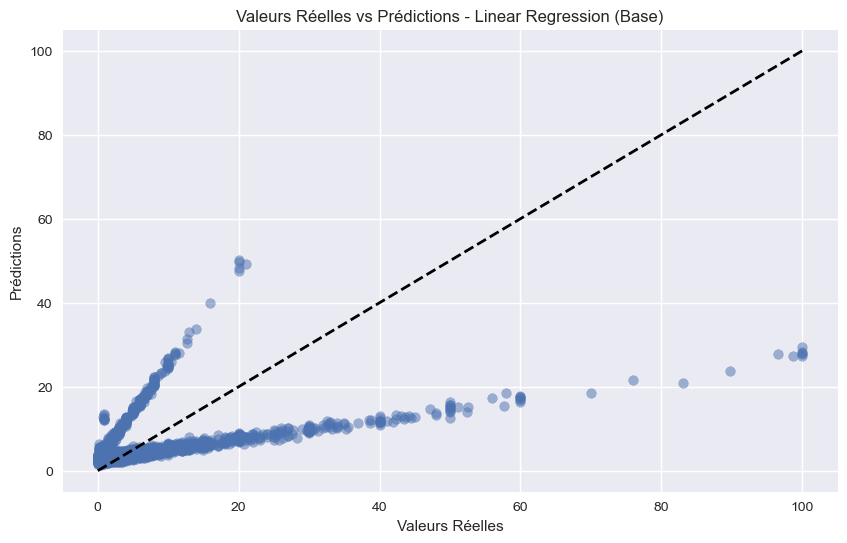

=== Résultats pour Ridge (alpha=1.0) (Base) ===
Train RMSE: 6.7345
Test RMSE: 7.0479
R² Score: 0.2963



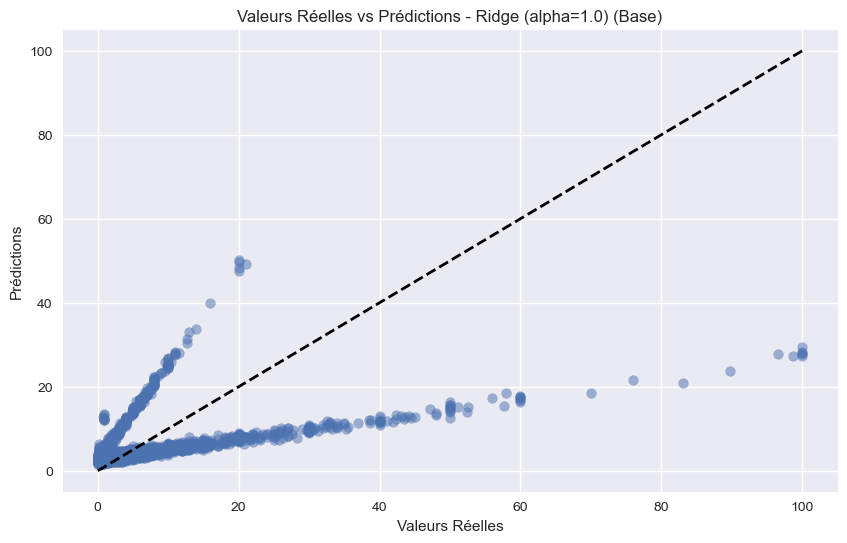

=== Résultats pour Lasso (alpha=0.1) (Base) ===
Train RMSE: 6.7417
Test RMSE: 7.0520
R² Score: 0.2955



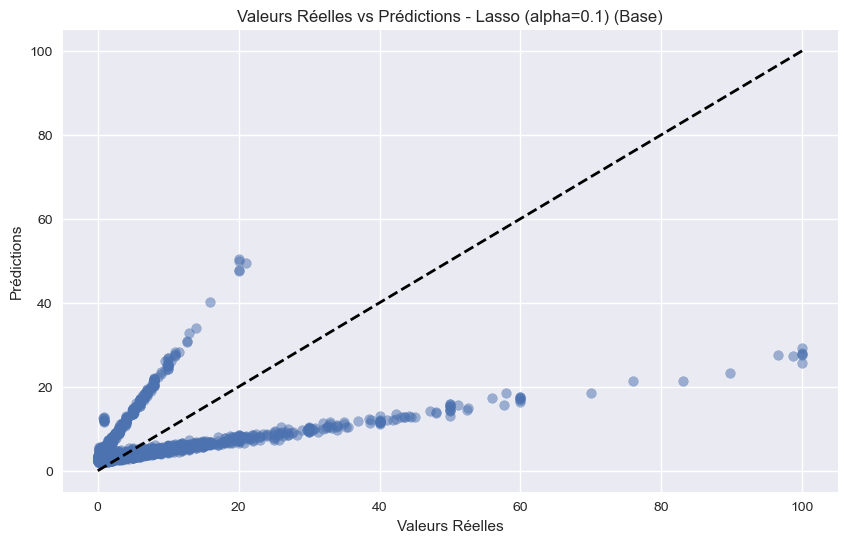

=== Résultats pour Decision Tree (Base) ===
Train RMSE: 0.0156
Test RMSE: 4.9119
R² Score: 0.6582



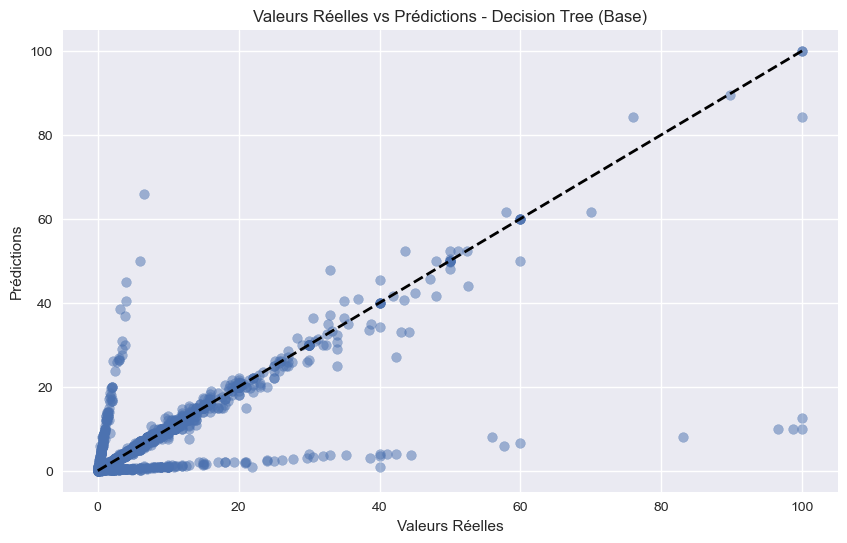

=== Résultats pour Random Forest (Base) ===
Train RMSE: 1.3017
Test RMSE: 3.8990
R² Score: 0.7846



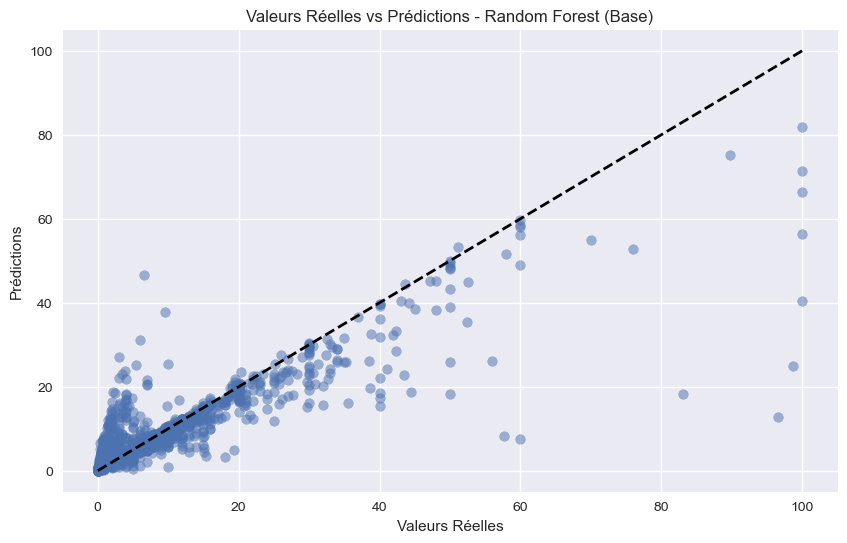

=== Résultats pour SVR (rbf) (Base) ===
Train RMSE: 6.7773
Test RMSE: 7.3261
R² Score: 0.2397



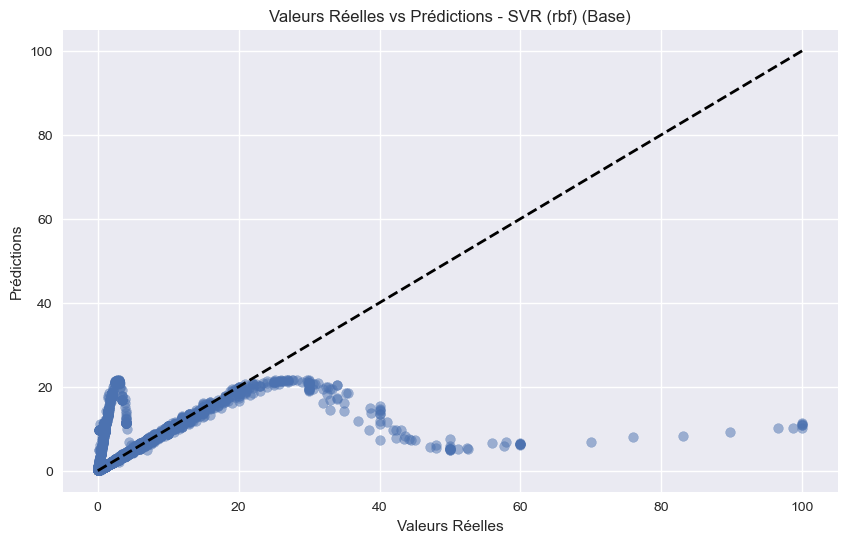

,model_name,train_rmse,test_rmse,r2
0,Linear Regression (Base),6.734480,7.047944,0.296329
1,Ridge (alpha=1.0) (Base),6.734480,7.047938,0.296330
2,Lasso (alpha=0.1) (Base),6.741731,7.052002,0.295518
3,Decision Tree (Base),0.015568,4.911893,0.658223
4,Random Forest (Base),1.301675,3.899029,0.784644
5,SVR (rbf) (Base),6.777340,7.326092,0.239692


In [9]:
if not df.empty:
    # Initialisation des modèles
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge (alpha=1.0)': Ridge(alpha=1.0),
        'Lasso (alpha=0.1)': Lasso(alpha=0.1),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'SVR (rbf)': SVR(kernel='rbf')
    }
    
    # Évaluation
    base_results = []
    for name, model in models.items():
        try:
            result = evaluate_model(model, X_train, X_test, y_train, y_test, f"{name} (Base)")
            base_results.append(result)
        except Exception as e:
            print(f"Erreur avec {name}: {str(e)}")
    
    # Conversion en DataFrame pour analyse
    base_results_df = pd.DataFrame(base_results).drop('model', axis=1)
    display(base_results_df)
else:
    print("Erreur: Impossible d'exécuter les modèles (DataFrame vide).")

In [10]:
if not df.empty:
    # Standardisation
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Réévaluation avec données normalisées
    scaled_results = []
    for name, model in models.items():
        try:
            # Recréer le modèle pour éviter tout biais
            new_model = clone(model)
            result = evaluate_model(
                new_model, 
                X_train_scaled, 
                X_test_scaled, 
                y_train, 
                y_test, 
                f"{name} (Scaled)",
                show_plot=False
            )
            scaled_results.append(result)
        except Exception as e:
            print(f"Erreur avec {name} (scaled): {str(e)}")
    
    scaled_results_df = pd.DataFrame(scaled_results).drop('model', axis=1)
    display(scaled_results_df)

Erreur avec Linear Regression (scaled): name 'clone' is not defined
Erreur avec Ridge (alpha=1.0) (scaled): name 'clone' is not defined
Erreur avec Lasso (alpha=0.1) (scaled): name 'clone' is not defined
Erreur avec Decision Tree (scaled): name 'clone' is not defined
Erreur avec Random Forest (scaled): name 'clone' is not defined
Erreur avec SVR (rbf) (scaled): name 'clone' is not defined


KeyError: "['model'] not found in axis"